#🌍 Climate change Trend Analysis

## This peoject analyzes global climae trends including:
- global average temperature
- co2 concentration
- temperature anomaly



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("climate_change.csv")
df.head()


,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
0,1980,Germany,14.16,1.16,44.70,4.89,401.23,1186.76,3.76,18.87,1,0.80,3,41.32,0.53,76.73,17.39,64,2.38,79.11
1,1980,France,14.58,1.07,36.49,6.81,447.54,962.89,3.67,13.94,16,1.37,2,27.46,0.97,79.31,59.17,122,2.57,26.32
2,1980,UK,15.22,1.16,40.82,2.06,404.95,1183.29,2.22,15.63,27,1.54,11,27.59,1.34,38.42,14.91,116,2.42,98.81
3,1980,India,13.80,1.04,34.28,7.44,400.59,970.50,3.24,16.03,47,2.70,0,67.23,3.23,65.22,25.46,98,2.69,31.10
4,1980,China,15.03,0.63,37.22,-3.24,390.74,1113.55,4.58,17.39,53,4.43,3,20.27,0.63,70.49,38.39,104,1.80,90.75


In [3]:
df.tail()

,year,country,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
1195,2025,Canada,14.02,0.88,36.41,-1.48,409.65,509.30,2.71,17.72,36,4.45,2,11.05,1.06,37.57,59.08,101,1.93,95.04
1196,2025,USA,13.88,1.14,39.49,5.39,442.96,1032.52,4.91,15.14,36,3.94,5,32.12,3.05,42.57,53.23,65,2.54,16.09
1197,2025,Pakistan,14.27,1.66,30.94,3.62,442.24,1344.71,4.17,18.46,41,3.49,6,18.79,0.37,34.91,27.52,199,2.33,30.04
1198,2025,India,14.50,1.06,39.85,5.11,467.16,862.48,-0.12,16.40,58,3.45,11,29.86,2.56,59.53,47.16,44,2.74,12.74
1199,2025,France,14.83,1.86,34.08,-3.56,383.71,904.99,4.18,16.93,40,3.48,13,15.45,2.57,35.16,34.37,45,1.85,25.40


### Data Cleaning 

In [4]:
df.info() # we can get data frame 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        1200 non-null   int64  
 1   country                     1200 non-null   object 
 2    global_avg_temperature     1200 non-null   float64
 3   temperature_anomaly         1200 non-null   float64
 4   max_temperature             1200 non-null   float64
 5   min_temperature             1200 non-null   float64
 6   co2_concentration_ppm       1200 non-null   float64
 7   annual_rainfall_mm          1200 non-null   float64
 8   sea_level_rise_mm           1200 non-null   float64
 9   sea_surface_temperature     1200 non-null   float64
 10  heatwave_days               1200 non-null   int64  
 11  drought_index               1200 non-null   float64
 12  flood_events_count          1200 non-null   int64  
 13  forest_cover_percent        1200 

In [5]:
df.describe() # summary of statistics 

,year,global_avg_temperature,temperature_anomaly,max_temperature,min_temperature,co2_concentration_ppm,annual_rainfall_mm,sea_level_rise_mm,sea_surface_temperature,heatwave_days,drought_index,flood_events_count,forest_cover_percent,deforestation_rate,fossil_fuel_consumption,renewable_energy_share,air_quality_index,predicted_temperature_2050,climate_risk_index
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000
mean,2002.452500,14.492850,1.095058,34.999692,4.775192,414.828717,993.087992,3.490333,16.472383,29.941667,2.533758,6.868333,39.162892,1.774992,54.906158,32.503275,120.682500,2.219142,49.61240
std,13.101493,0.594588,0.392627,4.915909,4.175590,25.528395,309.935917,1.190501,1.470498,17.266636,1.416269,4.271167,17.072966,0.992647,20.238368,16.002972,47.400904,0.486207,28.46554
min,1980.000000,12.420000,-0.230000,18.620000,-9.330000,331.310000,35.180000,-0.270000,11.320000,0.000000,0.020000,0.000000,10.030000,0.100000,20.020000,5.050000,40.000000,0.430000,0.11000
25%,1991.000000,14.080000,0.830000,31.730000,2.007500,397.592500,789.090000,2.680000,15.457500,15.000000,1.357500,3.000000,24.105000,0.907500,37.265000,18.997500,78.000000,1.890000,25.04500
50%,2003.000000,14.510000,1.090000,34.715000,4.850000,414.625000,998.040000,3.470000,16.460000,31.000000,2.495000,7.000000,39.345000,1.770000,54.965000,32.405000,123.000000,2.210000,49.96000
75%,2014.000000,14.910000,1.370000,38.267500,7.572500,432.180000,1204.387500,4.300000,17.440000,45.000000,3.692500,11.000000,53.400000,2.642500,72.002500,46.892500,164.000000,2.550000,72.79500
max,2025.000000,16.140000,2.320000,50.070000,17.960000,489.480000,2019.440000,7.750000,20.880000,59.000000,4.990000,14.000000,69.920000,3.500000,89.960000,59.960000,199.000000,3.770000,99.95000


In [6]:
missing_values = df.isnull().sum()
print(missing_values)

year                          0
country                       0
 global_avg_temperature       0
temperature_anomaly           0
max_temperature               0
min_temperature               0
co2_concentration_ppm         0
annual_rainfall_mm            0
sea_level_rise_mm             0
sea_surface_temperature       0
heatwave_days                 0
drought_index                 0
flood_events_count            0
forest_cover_percent          0
deforestation_rate            0
fossil_fuel_consumption       0
renewable_energy_share        0
air_quality_index             0
predicted_temperature_2050    0
climate_risk_index            0
dtype: int64


In [7]:
df.duplicated()
df['year'] = pd.to_datetime(df['year'], format = '%Y')# we change  data type int int0 datetime
df.columns = df.columns.str.strip().str.lower()
print(df.columns)
print(plt.style.available)

Index(['year', 'country', 'global_avg_temperature', 'temperature_anomaly',
       'max_temperature', 'min_temperature', 'co2_concentration_ppm',
       'annual_rainfall_mm', 'sea_level_rise_mm', 'sea_surface_temperature',
       'heatwave_days', 'drought_index', 'flood_events_count',
       'forest_cover_percent', 'deforestation_rate', 'fossil_fuel_consumption',
       'renewable_energy_share', 'air_quality_index',
       'predicted_temperature_2050', 'climate_risk_index'],
      dtype='object')
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks

### Visualizations

### Global Temperature Trend

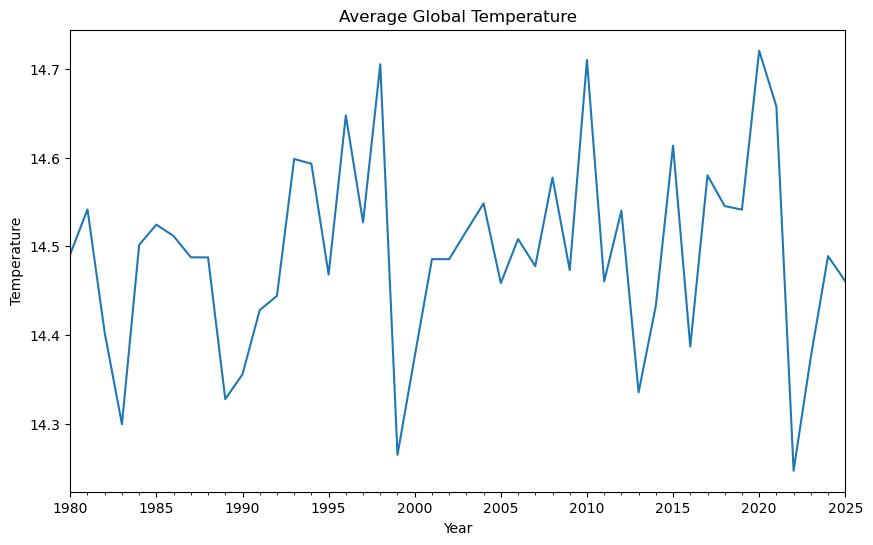

In [8]:

yearly_temp = df.groupby("year")["global_avg_temperature"].mean()
plt.figure(figsize=(10,6))
yearly_temp.plot()
plt.title("Average Global Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()
sns.set_theme(style = "whitegrid")

This graph show the movement of global temperature from 1980 to 2025. The red line represent the averge temperature of each year. We can see the temperature is fluctuates over time. However, the overall trend shows a gradual increase in global temperature and some years like around 1998, 2010 and 2020) show higher peaks, while a few years show the drops. Even thought the temperature is change every year the general pattern of this graph show global warming with temperatures slowly rising over the decades.

### Co2 concentration Trends.

In [9]:
df[["year", "co2_concentration_ppm"]]

,year,co2_concentration_ppm
0,1980-01-01,401.23
1,1980-01-01,447.54
2,1980-01-01,404.95
3,1980-01-01,400.59
4,1980-01-01,390.74
...,...,...
1195,2025-01-01,409.65
1196,2025-01-01,442.96
1197,2025-01-01,442.24
1198,2025-01-01,467.16


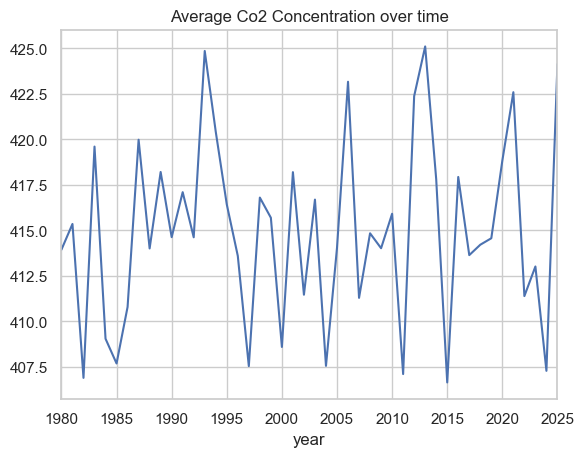

In [10]:
co2_trend = df.groupby("year")["co2_concentration_ppm"].mean()
plt.figure()
co2_trend.plot()
plt.title("Average Co2 Concentration over time")
plt.show()

Above graph shows the average  CO2 concentration mesured in ppm(parts per million) from around 1980 to 2025.The blue line represent yearly CO2 concentration levels. The value show year to year Fluctuations however, the overall trend show a gradual increase in CO2, concentration over time.Recent years have higher ppm values in compared to 1980s.

The increasing CO2 concentration (in ppm) indicates a rise in greenhouse gases in the atmoshper, which strongly linked to global warming and climate change.

### Top 10 Most Affected country


In [11]:
df[["country", "temperature_anomaly"]]

,country,temperature_anomaly
0,Germany,1.16
1,France,1.07
2,UK,1.16
3,India,1.04
4,China,0.63
...,...,...
1195,Canada,0.88
1196,USA,1.14
1197,Pakistan,1.66
1198,India,1.06


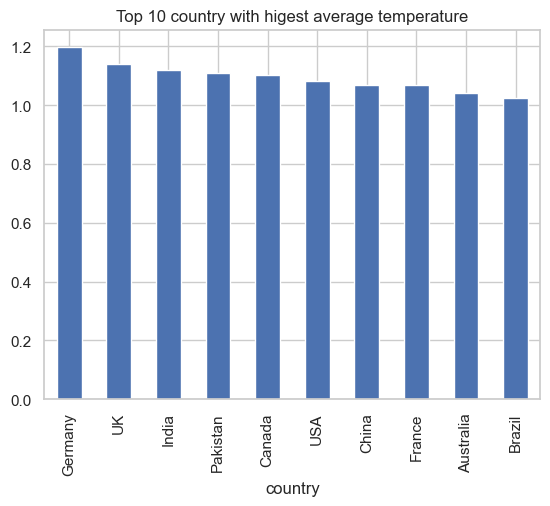

In [12]:
countries = df.groupby("country")["temperature_anomaly"].mean().sort_values(ascending=False)
plt.figure()
countries.plot(kind="bar")
plt.title("Top 10 country with higest average temperature")
plt.show()
plt.style.use("ggplot")


This bar chart shows the top 10 countriues with the highest average temperaature anomaly. Temperature anomly represent the difference between the observed temperature of a region. The chart indicates that countries such as German, UK, and India have higher positive anomally which simply mean that the cureent temperature is higher than historical average.

so the countries are experiencing significant warming trends, which highlights the impact of global climate change on regional temperatures.

In [13]:
df[["country", "sea_level_rise_mm"]]

,country,sea_level_rise_mm
0,Germany,3.76
1,France,3.67
2,UK,2.22
3,India,3.24
4,China,4.58
...,...,...
1195,Canada,2.71
1196,USA,4.91
1197,Pakistan,4.17
1198,India,-0.12


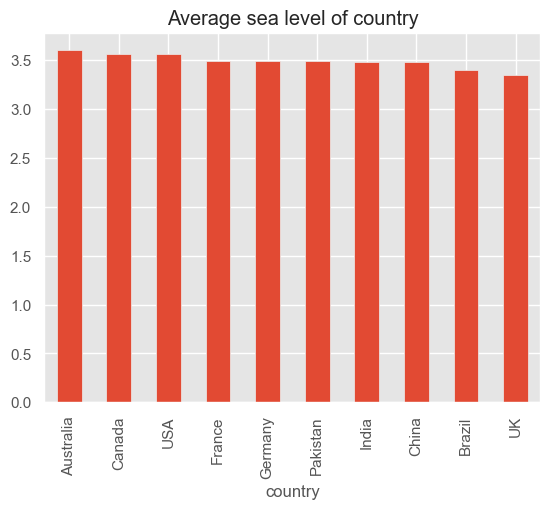

In [14]:
sea_level = df.groupby("country")["sea_level_rise_mm"].mean().sort_values(ascending = False)
plt.figure()
sea_level.plot(kind = "bar")
plt.title("Average sea level of country")
plt.style.use("fast")
plt.show()

This bar chart show the average sea level rise which is measured in millimeter (mm) for diffrent countries. Australia , Canada, and  USA show slightly higher sea level rise values. Other countries like Brazil and Uk have slightly lower value even thought it is noticeable.

The chart suggests that sea level are rising across multiple countries , which is an important indicator of climate change and global warming.Rising sea level can effect coastal area, ecosystem and human settlements.

## Conclusion

The analysis of climate data reveals clear indicators of long-term environmental change. The increase in CO₂ concentration (ppm) suggests a rising level of greenhouse gases in the atmosphere. Temperature trend and anomaly data show that many regions are experiencing temperatures above their historical averages. Additionally, the gradual rise in sea level (mm) indicates potential risks for coastal regions in the future. Overall, these patterns highlight the ongoing impact of climate change and emphasize the importance of monitoring environmental data and reducing greenhouse gas emissions.